a
Load the Iris dataset.
i) Explore the dataset by printing the first 4 rows including feature names and the target variable.
ii) Show the dataset's shape and summary statistics.
iii) Standardize the features and split the dataset into training (80%) and testing sets (20%).
b
Apply PCA to reduce the dataset to two principal components. Then, visualize the data in a 2D plot after applying PCA.
c
After applying PCA and standardization for dimensionality reduction, use the transformed dataset to train an Artificial Neural Network with one hidden layer. Compare the performance of the model with and without

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical


In [7]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species'] = df['species'].map(dict(enumerate(iris.target_names)))

print(df.head(4))

print("Shape: ", df.shape)
print("Stats: ", df.describe())

X = iris.data
y = iris.target
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
Shape:  (150, 5)
Stats:         sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   

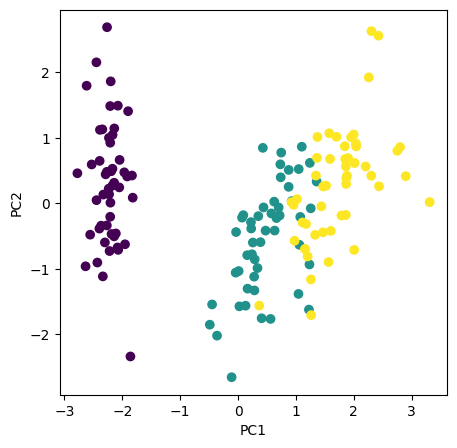

In [10]:
pca = PCA(n_components=2)
Xpca = pca.fit_transform(X_scaled)

plt.figure(figsize=(5,5))
plt.scatter(Xpca[:,0], Xpca[:,1],c=y)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

model1 = Sequential()
model1.add(Dense(10, activation='relu', input_dim=X_train.shape[1]))
model1.add(Dense(3, activation='softmax'))

model1.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

model1.fit(X_train, y_train, epochs=100, verbose=0)

y_pred1 = model1.predict(X_test)
y_pred1 = np.argmax(y_pred1, axis=1)

from sklearn.metrics import accuracy_score
print("Accuracy without PCA:", accuracy_score(y_test, y_pred1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Accuracy without PCA: 0.9


In [13]:
# split PCA data
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(Xpca, y, test_size=0.2)

model2 = Sequential()
model2.add(Dense(10, activation='relu', input_dim=X_train_pca.shape[1]))
model2.add(Dense(3, activation='softmax'))

model2.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

model2.fit(X_train_pca, y_train_pca, epochs=100, verbose=0)

y_pred2 = model2.predict(X_test_pca)
y_pred2 = np.argmax(y_pred2, axis=1)

print("Accuracy with PCA:", accuracy_score(y_test_pca, y_pred2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Accuracy with PCA: 0.9333333333333333


In [14]:
# split PCA data
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2)

model2 = Sequential()
model2.add(Dense(10, activation='relu', input_dim=X_train_pca.shape[1]))
model2.add(Dense(3, activation='softmax'))

model2.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

model2.fit(X_train_pca, y_train_pca, epochs=100, verbose=0)

y_pred2 = model2.predict(X_test_pca)
y_pred2 = np.argmax(y_pred2, axis=1)

print("Accuracy with PCA:", accuracy_score(y_test_pca, y_pred2))

NameError: name 'X_pca' is not defined